In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("waalbannyantudre/hate-speech-detection-curated-dataset")

print("Path to dataset files:", path)

Path to dataset files: /kaggle/input/datasets/waalbannyantudre/hate-speech-detection-curated-dataset


In [1]:
import os

path = "/kaggle/input/datasets/waalbannyantudre/hate-speech-detection-curated-dataset"
print(os.listdir(path))

['HateSpeechDatasetBalanced.csv', 'HateSpeechDataset.csv']


In [2]:
import pandas as pd
import numpy as np

In [ ]:
/kaggle/input/datasets/waalbannyantudre/hate-speech-detection-curated-dataset/HateSpeechDatasetBalanced.csv

In [3]:
path1="/kaggle/input/datasets/waalbannyantudre/hate-speech-detection-curated-dataset/HateSpeechDataset.csv"

In [4]:
new_df=pd.read_csv('/kaggle/input/datasets/waalbannyantudre/hate-speech-detection-curated-dataset/HateSpeechDatasetBalanced.csv')

In [5]:
new_df['Label'].value_counts()

Label
1    364525
0    361594
Name: count, dtype: int64

In [6]:
new_df.head()

,Content,Label
0,denial of normal the con be asked to comment o...,1
1,just by being able to tweet this insufferable ...,1
2,that is retarded you too cute to be single tha...,1
3,thought of a real badass mongol style declarat...,1
4,afro american basho,1


In [44]:
import os
print(os.listdir(path1))

NotADirectoryError: [Errno 20] Not a directory: '/kaggle/input/datasets/waalbannyantudre/hate-speech-detection-curated-dataset/HateSpeechDataset.csv'

In [7]:
chat_words = {
    "AFAIK": "as far as i know",
    "AFK": "away from keyboard",
    "ASAP": "as soon as possible",
    "ATM": "at the moment",
    "B4": "before",
    "B4N": "bye for now",
    "BAE": "before anyone else",
    "BB": "bye bye",
    "BBS": "be back soon",
    "BC": "because",
    "BF": "boyfriend",
    "BFF": "best friends forever",
    "BRB": "be right back",
    "BRO": "brother",
    "BTW": "by the way",
    "CYA": "see you",
    "CU": "see you",
    "CUL8R": "see you later",
    "DM": "direct message",
    "DIY": "do it yourself",
    "DND": "do not disturb",
    "EOD": "end of day",
    "F2F": "face to face",
    "FB": "facebook",
    "FF": "follow friday",
    "FOMO": "fear of missing out",
    "FTW": "for the win",
    "FYI": "for your information",
    "GF": "girlfriend",
    "GG": "good game",
    "GL": "good luck",
    "GN": "good night",
    "GM": "good morning",
    "G2G": "got to go",
    "GTG": "got to go",
    "GR8": "great",
    "HAND": "have a nice day",
    "HBD": "happy birthday",
    "HF": "have fun",
    "HMU": "hit me up",
    "ICYMI": "in case you missed it",
    "IDC": "i do not care",
    "IDK": "i do not know",
    "IKR": "i know right",
    "ILY": "i love you",
    "IMHO": "in my humble opinion",
    "IMO": "in my opinion",
    "IRL": "in real life",
    "JK": "just kidding",
    "JSYK": "just so you know",
    "K": "okay",
    "KK": "okay",
    "KTHX": "ok thanks",
    "L8R": "later",
    "LMK": "let me know",
    "LOL": "laughing out loud",
    "LMAO": "laughing my ass off",
    "LMFAO": "laughing my freaking ass off",
    "LTNS": "long time no see",
    "MFW": "my face when",
    "MRW": "my reaction when",
    "MSG": "message",
    "NBD": "no big deal",
    "NGL": "not gonna lie",
    "NM": "not much",
    "NVM": "never mind",
    "NP": "no problem",
    "NSFW": "not safe for work",
    "OFC": "of course",
    "OMG": "oh my god",
    "OMW": "on my way",
    "OP": "original poster",
    "OT": "off topic",
    "OTP": "one true pairing",
    "PPL": "people",
    "PLS": "please",
    "PLZ": "please",
    "POV": "point of view",
    "ROFL": "rolling on the floor laughing",
    "RN": "right now",
    "SMH": "shaking my head",
    "SRY": "sorry",
    "SUP": "what is up",
    "TBH": "to be honest",
    "TBA": "to be announced",
    "TBC": "to be continued",
    "TBD": "to be decided",
    "TGIF": "thank god it is friday",
    "THX": "thanks",
    "TIA": "thanks in advance",
    "TMI": "too much information",
    "TTYL": "talk to you later",
    "TY": "thank you",
    "TYSM": "thank you so much",
    "U": "you",
    "UR": "your",
    "URS": "yours",
    "W8": "wait",
    "WB": "welcome back",
    "WBU": "what about you",
    "WTF": "what the hell",
    "WTH": "what the heck",
    "WYWH": "wish you were here",
    "XOXO": "hugs and kisses",
    "Y": "why",
    "YA": "you",
    "YEA": "yeah",
    "YEP": "yes",
    "YOLO": "you only live once",
    "YW": "you are welcome"
}

In [8]:
import re
import string
import nltk
import emoji
from bs4 import BeautifulSoup
from textblob import TextBlob

from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer, WordNetLemmatizer

nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package punkt to /usr/share/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /usr/share/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /usr/share/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [9]:
def chat_conversion(text):
    words = text.split()
    new_text = []

    for w in words:
        if w.upper() in chat_words:
            new_text.append(chat_words[w.upper()])
        else:
            new_text.append(w)

    return " ".join(new_text)

In [10]:
def remove_html(text):
    return BeautifulSoup(text, "html.parser").get_text()

In [11]:
def remove_urls(text):
    return re.sub(r'https?://\S+|www\.\S+', '', text)

In [12]:
def remove_punctuation(text):
    return text.translate(str.maketrans('', '', string.punctuation))

In [13]:
def convert_emojis(text):
    return emoji.demojize(text)

In [14]:
def correct_spelling(text):
    return str(TextBlob(text).correct())

In [15]:
new_df["step1_lower"] =new_df["Content"].apply(lambda x: x.lower())

In [17]:
new_df.head()

,Content,Label,step1_lower
0,denial of normal the con be asked to comment o...,1,denial of normal the con be asked to comment o...
1,just by being able to tweet this insufferable ...,1,just by being able to tweet this insufferable ...
2,that is retarded you too cute to be single tha...,1,that is retarded you too cute to be single tha...
3,thought of a real badass mongol style declarat...,1,thought of a real badass mongol style declarat...
4,afro american basho,1,afro american basho


In [18]:
new_df["step2_html_removed"] = new_df["step1_lower"].apply(remove_html)

In [19]:
new_df.head()

,Content,Label,step1_lower,step2_html_removed
0,denial of normal the con be asked to comment o...,1,denial of normal the con be asked to comment o...,denial of normal the con be asked to comment o...
1,just by being able to tweet this insufferable ...,1,just by being able to tweet this insufferable ...,just by being able to tweet this insufferable ...
2,that is retarded you too cute to be single tha...,1,that is retarded you too cute to be single tha...,that is retarded you too cute to be single tha...
3,thought of a real badass mongol style declarat...,1,thought of a real badass mongol style declarat...,thought of a real badass mongol style declarat...
4,afro american basho,1,afro american basho,afro american basho


In [20]:
new_df["step3_url_removed"] = new_df["step2_html_removed"].apply(remove_urls)

In [21]:
new_df.head()

,Content,Label,step1_lower,step2_html_removed,step3_url_removed
0,denial of normal the con be asked to comment o...,1,denial of normal the con be asked to comment o...,denial of normal the con be asked to comment o...,denial of normal the con be asked to comment o...
1,just by being able to tweet this insufferable ...,1,just by being able to tweet this insufferable ...,just by being able to tweet this insufferable ...,just by being able to tweet this insufferable ...
2,that is retarded you too cute to be single tha...,1,that is retarded you too cute to be single tha...,that is retarded you too cute to be single tha...,that is retarded you too cute to be single tha...
3,thought of a real badass mongol style declarat...,1,thought of a real badass mongol style declarat...,thought of a real badass mongol style declarat...,thought of a real badass mongol style declarat...
4,afro american basho,1,afro american basho,afro american basho,afro american basho


In [30]:
new_df["step4_chat_converted"] = new_df["step3_url_removed"].apply(chat_conversion)

In [31]:
new_df.head()

,Content,Label,step1_lower,step2_html_removed,step3_url_removed,step4_chat_converted
0,denial of normal the con be asked to comment o...,1,denial of normal the con be asked to comment o...,denial of normal the con be asked to comment o...,denial of normal the con be asked to comment o...,denial of normal the con be asked to comment o...
1,just by being able to tweet this insufferable ...,1,just by being able to tweet this insufferable ...,just by being able to tweet this insufferable ...,just by being able to tweet this insufferable ...,just by being able to tweet this insufferable ...
2,that is retarded you too cute to be single tha...,1,that is retarded you too cute to be single tha...,that is retarded you too cute to be single tha...,that is retarded you too cute to be single tha...,that is retarded you too cute to be single tha...
3,thought of a real badass mongol style declarat...,1,thought of a real badass mongol style declarat...,thought of a real badass mongol style declarat...,thought of a real badass mongol style declarat...,thought of a real badass mongol style declarat...
4,afro american basho,1,afro american basho,afro american basho,afro american basho,afro american basho


In [32]:
new_df["step5_emoji_converted"] = new_df["step4_chat_converted"].apply(convert_emojis)

In [33]:
new_df.head()

,Content,Label,step1_lower,step2_html_removed,step3_url_removed,step4_chat_converted,step5_emoji_converted
0,denial of normal the con be asked to comment o...,1,denial of normal the con be asked to comment o...,denial of normal the con be asked to comment o...,denial of normal the con be asked to comment o...,denial of normal the con be asked to comment o...,denial of normal the con be asked to comment o...
1,just by being able to tweet this insufferable ...,1,just by being able to tweet this insufferable ...,just by being able to tweet this insufferable ...,just by being able to tweet this insufferable ...,just by being able to tweet this insufferable ...,just by being able to tweet this insufferable ...
2,that is retarded you too cute to be single tha...,1,that is retarded you too cute to be single tha...,that is retarded you too cute to be single tha...,that is retarded you too cute to be single tha...,that is retarded you too cute to be single tha...,that is retarded you too cute to be single tha...
3,thought of a real badass mongol style declarat...,1,thought of a real badass mongol style declarat...,thought of a real badass mongol style declarat...,thought of a real badass mongol style declarat...,thought of a real badass mongol style declarat...,thought of a real badass mongol style declarat...
4,afro american basho,1,afro american basho,afro american basho,afro american basho,afro american basho,afro american basho


In [34]:
new_df["step6_no_punctuation"] = new_df["step5_emoji_converted"].apply(remove_punctuation)

In [29]:
!pip install pyspellchecker

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.2/7.2 MB 56.9 MB/s eta 0:00:0000:0100:01


In [32]:
from spellchecker import SpellChecker

spell = SpellChecker()

def correct_spelling_fast(text):

    if not isinstance(text, str):
        return ""

    words = text.split()

    
    misspelled = spell.unknown(words)

    
    corrections = {word: spell.correction(word) for word in misspelled}

    
    corrected_words = [
        corrections[word] if word in corrections and corrections[word] is not None else word
        for word in words
    ]

    return " ".join(corrected_words)

In [ ]:
new_df["step7_spell_correct"] = new_df["step6_no_punctuation"].apply(correct_spelling_fast)

In [ ]:
# from nltk.tokenize import word_tokenize

# new_df["step8_tokens"] = new_df["step7_spell_correct"].apply(word_tokenize)

In [35]:
from nltk.tokenize import word_tokenize

new_df["step8_tokens"] = new_df["step6_no_punctuation"].apply(word_tokenize)

In [36]:
new_df["step8_tokens"].sample(10)

686524    [the, father, prado, in, jim, do, laze, take, ...
402521    [well, for, a, start, it, is, not, specific, e...
264860    [i, had, it, in, my, edit, comments, but, i, w...
334190    [mediation, i, know, whatever, have, not, exac...
451359    [jews, should, eat, the, same, food, as, us, c...
442946    [iodin, for, ace, plan, to, hang, the, last, h...
529855    [skinny, is, really, not, healthy, tell, that,...
288223    [please, refrain, from, changing, music, genre...
718148    [either, sort, reckons, wrongly, that, you, ar...
539203    [she, can, get, whatever, he, is, he, does, no...
Name: step8_tokens, dtype: object

In [37]:
from nltk.corpus import stopwords

stop_words = set(stopwords.words('english'))

keep_words = {

"no","not","nor","never","none","nothing","nowhere","neither",

"don't","doesn't","didn't","can't","couldn't","won't","wouldn't",
"shouldn't","mustn't","isn't","aren't","wasn't","weren't",
"haven't","hasn't","hadn't","ain't",

"i","me","my","mine","myself",
"we","us","our","ours","ourselves",
"you","your","yours","yourself","yourselves",
"he","him","his","himself",
"she","her","hers","herself",
"they","them","their","theirs","themselves"
}

stop_words = stop_words - keep_words

def remove_stopwords(tokens):
    return [word for word in tokens if word not in stop_words]

In [38]:
new_df["step9_no_stopwords"] = new_df["step8_tokens"].apply(remove_stopwords)

In [39]:
from nltk.stem import WordNetLemmatizer

lemmatizer = WordNetLemmatizer()

def apply_lemmatization(tokens):
    return [lemmatizer.lemmatize(word, pos='v') for word in tokens]

In [40]:
new_df["step10_lemmataization"] = new_df["step9_no_stopwords"].apply(apply_lemmatization)

In [41]:
new_df["step10_lemmataization"].sample(10)

349012    [utc, base, you, wikipedia, work, anonymous, u...
264631    [reference, external, link, name, justice, tri...
586319    [women, ban, commit, crime, they, not, make, d...
58373                   [you, realize, you, mass, murderer]
330790    [your, recent, disruptive, edit, ward, churchi...
317237    [you, get, text, make, you, jump, your, seat, ...
122782    [i, blame, school, us, ethics, multicult, love...
57742     [stupid, bitch, talk, utter, shit, woman, pure...
427789    [your, go, ahead, nomination, generation, effe...
111574    [i, love, kid, get, put, their, place, little,...
Name: step10_lemmataization, dtype: object

In [42]:
new_df.head()

,Content,Label,step1_lower,step2_html_removed,step3_url_removed,step4_chat_converted,step5_emoji_converted,step6_no_punctuation,step8_tokens,step9_no_stopwords,step10_lemmataization
0,denial of normal the con be asked to comment o...,1,denial of normal the con be asked to comment o...,denial of normal the con be asked to comment o...,denial of normal the con be asked to comment o...,denial of normal the con be asked to comment o...,denial of normal the con be asked to comment o...,denial of normal the con be asked to comment o...,"[denial, of, normal, the, con, be, asked, to, ...","[denial, normal, con, asked, comment, tragedie...","[denial, normal, con, ask, comment, tragedies,..."
1,just by being able to tweet this insufferable ...,1,just by being able to tweet this insufferable ...,just by being able to tweet this insufferable ...,just by being able to tweet this insufferable ...,just by being able to tweet this insufferable ...,just by being able to tweet this insufferable ...,just by being able to tweet this insufferable ...,"[just, by, being, able, to, tweet, this, insuf...","[able, tweet, insufferable, bullshit, proves, ...","[able, tweet, insufferable, bullshit, prove, t..."
2,that is retarded you too cute to be single tha...,1,that is retarded you too cute to be single tha...,that is retarded you too cute to be single tha...,that is retarded you too cute to be single tha...,that is retarded you too cute to be single tha...,that is retarded you too cute to be single tha...,that is retarded you too cute to be single tha...,"[that, is, retarded, you, too, cute, to, be, s...","[retarded, you, cute, single, life]","[retard, you, cute, single, life]"
3,thought of a real badass mongol style declarat...,1,thought of a real badass mongol style declarat...,thought of a real badass mongol style declarat...,thought of a real badass mongol style declarat...,thought of a real badass mongol style declarat...,thought of a real badass mongol style declarat...,thought of a real badass mongol style declarat...,"[thought, of, a, real, badass, mongol, style, ...","[thought, real, badass, mongol, style, declara...","[think, real, badass, mongol, style, declarati..."
4,afro american basho,1,afro american basho,afro american basho,afro american basho,afro american basho,afro american basho,afro american basho,"[afro, american, basho]","[afro, american, basho]","[afro, american, basho]"


In [43]:
def tokens_to_sentence(tokens):

    return " ".join(tokens)

In [44]:
new_df["text"] = new_df["step10_lemmataization"].apply(tokens_to_sentence)

In [45]:
new_df.head()

,Content,Label,step1_lower,step2_html_removed,step3_url_removed,step4_chat_converted,step5_emoji_converted,step6_no_punctuation,step8_tokens,step9_no_stopwords,step10_lemmataization,text
0,denial of normal the con be asked to comment o...,1,denial of normal the con be asked to comment o...,denial of normal the con be asked to comment o...,denial of normal the con be asked to comment o...,denial of normal the con be asked to comment o...,denial of normal the con be asked to comment o...,denial of normal the con be asked to comment o...,"[denial, of, normal, the, con, be, asked, to, ...","[denial, normal, con, asked, comment, tragedie...","[denial, normal, con, ask, comment, tragedies,...",denial normal con ask comment tragedies emotio...
1,just by being able to tweet this insufferable ...,1,just by being able to tweet this insufferable ...,just by being able to tweet this insufferable ...,just by being able to tweet this insufferable ...,just by being able to tweet this insufferable ...,just by being able to tweet this insufferable ...,just by being able to tweet this insufferable ...,"[just, by, being, able, to, tweet, this, insuf...","[able, tweet, insufferable, bullshit, proves, ...","[able, tweet, insufferable, bullshit, prove, t...",able tweet insufferable bullshit prove trump n...
2,that is retarded you too cute to be single tha...,1,that is retarded you too cute to be single tha...,that is retarded you too cute to be single tha...,that is retarded you too cute to be single tha...,that is retarded you too cute to be single tha...,that is retarded you too cute to be single tha...,that is retarded you too cute to be single tha...,"[that, is, retarded, you, too, cute, to, be, s...","[retarded, you, cute, single, life]","[retard, you, cute, single, life]",retard you cute single life
3,thought of a real badass mongol style declarat...,1,thought of a real badass mongol style declarat...,thought of a real badass mongol style declarat...,thought of a real badass mongol style declarat...,thought of a real badass mongol style declarat...,thought of a real badass mongol style declarat...,thought of a real badass mongol style declarat...,"[thought, of, a, real, badass, mongol, style, ...","[thought, real, badass, mongol, style, declara...","[think, real, badass, mongol, style, declarati...",think real badass mongol style declaration war...
4,afro american basho,1,afro american basho,afro american basho,afro american basho,afro american basho,afro american basho,afro american basho,"[afro, american, basho]","[afro, american, basho]","[afro, american, basho]",afro american basho


In [47]:
from sklearn.feature_extraction.text import CountVectorizer

vectorizer = CountVectorizer(
    ngram_range=(1,2),
    max_features=5000
)

X1 = vectorizer.fit_transform(new_df["text"])

In [72]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(
    ngram_range=(1,2),
    max_features=5000
)

X2 = vectorizer.fit_transform(new_df["text"])

In [49]:
new_df["Label"].value_counts()

Label
1    364525
0    361594
Name: count, dtype: int64

In [50]:
from sklearn.model_selection import train_test_split

X1_train, X1_test, y1_train, y1_test = train_test_split(
    X1,
    new_df["Label"],
    test_size=0.2,
    random_state=42
)

In [51]:
X2_train, X2_test, y2_train, y2_test = train_test_split(
    X2,
    new_df["Label"],
    test_size=0.2,
    random_state=42
)

In [ ]:
X = df["text"]      
y = df["Label"]  

In [52]:
import multiprocessing
cores = multiprocessing.cpu_count()

In [54]:
print(cores)

4


In [56]:
sentences = new_df["step10_lemmataization"].tolist()

In [58]:
from gensim.models import Word2Vec
w2v_model = Word2Vec(
    sentences=sentences,
    vector_size=200,
    window=5,
    min_count=2,
    workers=cores,
    sg=1,
    epochs=5
)

In [59]:
def get_vector(tokens, model):

    vectors = []

    for word in tokens:
        if word in model.wv:
            vectors.append(model.wv[word])

    if len(vectors) == 0:
        return np.zeros(model.vector_size)

    return np.mean(vectors, axis=0)

In [60]:
X_w2v = np.array([get_vector(tokens, w2v_model) for tokens in sentences])

In [61]:
from sklearn.model_selection import train_test_split

X_train_w2v, X_test_w2v, y_train_w2v, y_test_w2v = train_test_split(
    X_w2v,
    new_df["Label"],
    test_size=0.2,
    random_state=42,
    stratify=new_df["Label"]
)

In [ ]:
from gensim.models import Word2Vec

w2v_model = Word2Vec(
    train_tokens,      
    vector_size=100,
    window=5,
    min_count=2,
    workers=4         
)

In [62]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import BernoulliNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [63]:
bnb1= BernoulliNB()
bnb1.fit(X_train_w2v, y_train_w2v)

BernoulliNB()

In [64]:
y_pred = bnb1.predict(X_test_w2v)

In [66]:
print("Accuracy:", accuracy_score(y_test_w2v, y_pred))
print(classification_report(y_test_w2v, y_pred))

Accuracy: 0.7232895389191869
              precision    recall  f1-score   support

           0       0.74      0.69      0.71     72319
           1       0.71      0.76      0.73     72905

    accuracy                           0.72    145224
   macro avg       0.72      0.72      0.72    145224
weighted avg       0.72      0.72      0.72    145224



In [67]:
bnb2= BernoulliNB()
bnb2.fit(X1_train, y1_train)

BernoulliNB()

In [70]:
y_pred2 = bnb2.predict(X1_test)

In [71]:
print("Accuracy:", accuracy_score(y1_test, y_pred2))
print(classification_report(y1_test, y_pred2))

Accuracy: 0.7096554288547348
              precision    recall  f1-score   support

           0       0.85      0.50      0.63     72043
           1       0.65      0.91      0.76     73181

    accuracy                           0.71    145224
   macro avg       0.75      0.71      0.70    145224
weighted avg       0.75      0.71      0.70    145224



In [73]:
bnb3= BernoulliNB()
bnb3.fit(X2_train, y2_train)

BernoulliNB()

In [74]:
y_pred3=bnb3.predict(X2_test)

In [75]:
print("Accuracy:", accuracy_score(y2_test, y_pred3))
print(classification_report(y2_test, y_pred3))

Accuracy: 0.7137869773591142
              precision    recall  f1-score   support

           0       0.86      0.50      0.64     72043
           1       0.65      0.92      0.76     73181

    accuracy                           0.71    145224
   macro avg       0.76      0.71      0.70    145224
weighted avg       0.76      0.71      0.70    145224



In [76]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense

2026-03-11 15:55:32.219382: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1773244532.640951      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1773244532.749059      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1773244533.720102      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1773244533.720136      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1773244533.720139      55 computation_placer.cc:177] computation placer alr

In [77]:
tokenizer = Tokenizer(num_words=10000)

tokenizer.fit_on_texts(new_df["text"])

sequences = tokenizer.texts_to_sequences(new_df["text"])

In [78]:
max_len = 100

X_seq = pad_sequences(sequences, maxlen=max_len)

In [79]:
X_train_lstm, X_test_lstm, y_train_lstm, y_test_lstm = train_test_split(
    X_seq,
    new_df["Label"],
    test_size=0.2,
    random_state=42,
    stratify=new_df["Label"]
)

In [87]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout, Input

model = Sequential()

model.add(Input(shape=(100,)))


model.add(Embedding(
    input_dim=10000,
    output_dim=128
))


model.add(LSTM(128, return_sequences=True))
model.add(LSTM(64, return_sequences=True))
model.add(LSTM(32))


model.add(Dropout(0.3))


model.add(Dense(1, activation="sigmoid"))

In [88]:
model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

In [89]:
history = model.fit(
    X_train_lstm,
    y_train_lstm,
    epochs=5,
    batch_size=32,
    validation_data=(X_test_lstm, y_test_lstm)
)

Epoch 1/5


I0000 00:00:1773245200.304312     385 cuda_dnn.cc:529] Loaded cuDNN version 91002


18153/18153 ━━━━━━━━━━━━━━━━━━━━ 284s 15ms/step - accuracy: 0.8084 - loss: 0.4081 - val_accuracy: 0.8459 - val_loss: 0.3399
Epoch 2/5
18153/18153 ━━━━━━━━━━━━━━━━━━━━ 278s 15ms/step - accuracy: 0.8621 - loss: 0.3099 - val_accuracy: 0.8569 - val_loss: 0.3193
Epoch 3/5
18153/18153 ━━━━━━━━━━━━━━━━━━━━ 279s 15ms/step - accuracy: 0.8828 - loss: 0.2679 - val_accuracy: 0.8627 - val_loss: 0.3112
Epoch 4/5
18153/18153 ━━━━━━━━━━━━━━━━━━━━ 279s 15ms/step - accuracy: 0.9007 - loss: 0.2310 - val_accuracy: 0.8643 - val_loss: 0.3147
Epoch 5/5
18153/18153 ━━━━━━━━━━━━━━━━━━━━ 278s 15ms/step - accuracy: 0.9182 - loss: 0.1948 - val_accuracy: 0.8651 - val_loss: 0.3245


In [90]:
loss, accuracy = model.evaluate(X_test_lstm, y_test_lstm)

print("Test Loss:", loss)
print("Test Accuracy:", accuracy)

4539/4539 ━━━━━━━━━━━━━━━━━━━━ 29s 6ms/step - accuracy: 0.8642 - loss: 0.3252
Test Loss: 0.32450050115585327
Test Accuracy: 0.8650773763656616


In [95]:
y_pred= (model.predict(X_test_lstm) > 0.5).astype(int)
print("Predictions (0=Non-Hate, 1=Hate):")
print(y_pred[:10])
def predict_hate(text):
    seq = tokenizer.texts_to_sequences([text])
    seq = pad_sequences(seq, maxlen=100)
    pred = model.predict(seq)
    return int(pred > 0.5)

sentence = "you are a good boy"
print("Prediction for sentence:", predict_hate(sentence))

4539/4539 ━━━━━━━━━━━━━━━━━━━━ 23s 5ms/step
Predictions (0=Non-Hate, 1=Hate):
[[0]
 [0]
 [0]
 [1]
 [1]
 [1]
 [0]
 [1]
 [0]
 [0]]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
Prediction for sentence: 0


/tmp/ipykernel_55/2203432775.py:8: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  return int(pred > 0.5)


In [96]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

In [97]:
y_pred_prob = model.predict(X_test_lstm).ravel() 

4539/4539 ━━━━━━━━━━━━━━━━━━━━ 23s 5ms/step


In [98]:
fpr, tpr, thresholds = roc_curve(y_test_lstm, y_pred_prob)
roc_auc = auc(fpr, tpr)
print("AUC:", roc_auc)

AUC: 0.9410701996876216


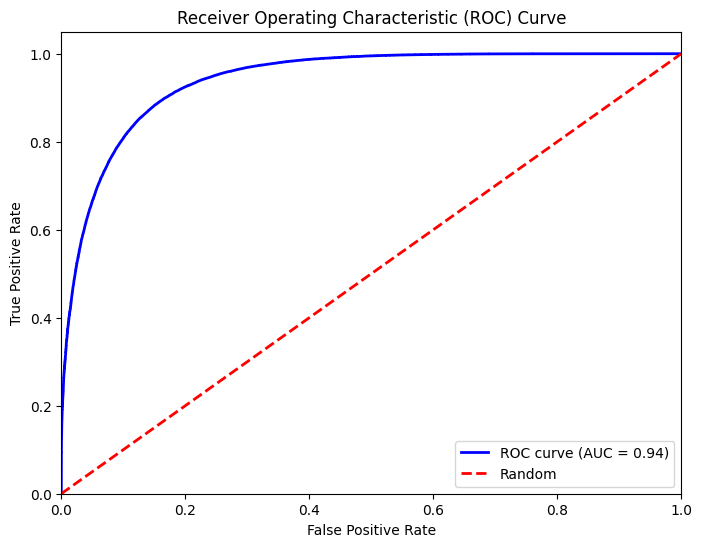

In [99]:
plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, color='blue', lw=2, label='ROC curve (AUC = %0.2f)' % roc_auc)
plt.plot([0,1], [0,1], color='red', lw=2, linestyle='--', label='Random')
plt.xlim([0.0,1.0])
plt.ylim([0.0,1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.show()

In [100]:
import numpy as np

J = tpr - fpr
ix = np.argmax(J)

best_threshold = thresholds[ix]

print("Best Threshold:", best_threshold)
print("TPR:", tpr[ix])
print("FPR:", fpr[ix])

Best Threshold: 0.4412932
TPR: 0.8901721418284069
FPR: 0.15751047442580787
